In [1]:
import os
import pickle
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [2]:

video_path = r"C:\Users\User\Desktop\deeplearning\fusion\video_features_256.pkl"
audio_path = r"C:\Users\User\Desktop\deeplearning\fusion\audio_feat_hubert_origin.pkl"
text_path = r"C:\Users\User\Desktop\deeplearning\fusion\text_features_256(basic+earlystop).pkl"

# 2199개 샘플, 이미지 높이 224, 이미지 너비 224, RGB 3채널
with open(video_path, "rb") as f: 
    video_data = pickle.load(f)
X_video = video_data["features"]
X_video_labels = video_data["labels"] 



with open(audio_path, "rb") as f:
    audio_data = pickle.load(f)
X_audio = audio_data["audio_feat"]
X_audio_labels = audio_data["labels"]


text_data = torch.load(text_path,map_location=device)
X_text = text_data["features"]
X_text_labels = text_data["labels"]

# with open(text_path, "rb") as f:
#     text_data = pickle.load(f)
# X_text = text_data["features"]
# X_text_labels = text_data["labels"]

X_video_labels = torch.as_tensor(X_video_labels).long()
X_audio_labels = torch.as_tensor(X_audio_labels).long()
X_text_labels = torch.as_tensor(X_text_labels).long()


print(f"X_video      : {X_video.shape} ") # (224, 224, 3)
print(f"X_video_labels: (긍정 {X_video_labels.sum()} / 부정 {(X_video_labels==0).sum()})")

print(f"X_audio      : {X_audio.shape} ")
print(f"X_audio_labels: (긍정 {X_audio_labels.sum()} / 부정 {(X_audio_labels==0).sum()})")

print(f"X_text      : {X_text.shape} ")
print(f"X_text_labels: (긍정 {X_text_labels.sum()} / 부정 {(X_text_labels==0).sum()})")


X_video      : torch.Size([2199, 256]) 
X_video_labels: (긍정 1176 / 부정 1023)
X_audio      : torch.Size([2199, 256]) 
X_audio_labels: (긍정 1080 / 부정 1119)
X_text      : torch.Size([2199, 256]) 
X_text_labels: (긍정 1080 / 부정 1119)


그러나 라벨 분포가 video만 다르다

In [3]:
X_video_labels = torch.as_tensor(X_video_labels).cpu()
X_audio_labels = torch.as_tensor(X_audio_labels).cpu()
X_text_labels = torch.as_tensor(X_text_labels).cpu()

print(torch.equal(X_audio_labels, X_text_labels))
print(torch.equal(X_video_labels, X_text_labels))
print(torch.equal(X_video_labels, X_audio_labels))

True
False
False


feature 차원 기준 concat은 가능하나 label 기준 video 라벨이 달라 확인 필요
각자 차원수 맞춰왔으니 각 모달리티별 인코더 생략 가능

In [4]:
import torch.nn as nn

X_video = X_video.to(device)
X_audio = X_audio.to(device)
X_text = X_text.to(device)

# 세 모달리티 concat → MLP
fused = torch.cat([X_video, X_audio, X_text], dim=1)  # (N, 768)

input_dim = fused.shape[1]  # 768 + 768 + 768 = 2304


mlp = nn.Sequential(
    nn.Linear(input_dim, 256), 
    nn.ReLU(), 
    nn.Dropout(0.3),
    nn.Linear(256, 2)
)

y = torch.as_tensor(X_text_labels).long().to(device)  # (N,)

print(fused.shape)  # (N, 2304)
print(y.shape)
print(fused.device)

torch.Size([2199, 768])
torch.Size([2199])
cuda:0


In [5]:
# train / val / test split
N = fused.shape[0]
indices = torch.randperm(N,device=device)

train_size = int(0.7 * N)
val_size = int(0.15 * N)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

X_train, y_train = fused[train_idx], y[train_idx]
X_val, y_val = fused[val_idx], y[val_idx]
X_test, y_test = fused[test_idx], y[test_idx]

In [6]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score

In [7]:
#DataLoader
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=32,
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=32,
    shuffle=False
)


In [8]:
MLP = nn.Sequential(
    nn.Linear(input_dim, 256), 
    nn.BatchNorm1d(256),
    nn.ReLU(), 
    nn.Dropout(0.5),
    nn.Linear(256, 3)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(MLP.parameters(), lr=1e-3)


In [9]:
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() 

            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, acc, prec, rec, f1

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp = mlp.to(device)

optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []


epochs = 20

for epoch in range(epochs):
    mlp.train()
    total_loss = 0

for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    optimizer.zero_grad()

    outputs = mlp(X_batch)
    loss = criterion(outputs, y_batch)

    loss.backward()
    optimizer.step()

In [11]:
print(next(mlp.parameters()).device)
print(fused.device)

cuda:0
cuda:0


In [12]:
mlp = mlp.to(fused.device)
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)

print(next(mlp.parameters()).device)
print(fused.device)

cuda:0
cuda:0


In [13]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_prec": [],
    "train_rec": [],
    "train_f1": [], 

    "val_loss": [],
    "val_acc": [],
    "val_prec": [],
    "val_rec": [],
    "val_f1": [],

    "test_loss": [],
    "test_acc": [],
    "test_prec": [],
    "test_rec": [],
    "test_f1": []
}

epochs = 20

# Early Stopping
best_val_loss = float("inf")
patience_counter = 0
patience = 4  
best_model_state = None
best_epoch = 0


for epoch in range(epochs):
    mlp.train()
    
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = mlp(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    train_loss, train_acc, train_prec, train_rec, train_f1 = evaluate(mlp, train_loader)
    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(mlp, val_loader)
    test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(mlp, test_loader)

    # print(f"Epoch {epoch+1}/{epochs} ")
    # print(f"Loss: {train_loss:.4f} ")
    # print(f"Val Acc: {val_acc:.4f} ")
    # print(f"Val Prec: {val_prec:.4f} ")
    # print(f"Val Rec: {val_rec:.4f} ")
    # print(f"Val F1: {val_f1:.4f}")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_prec"].append(train_prec)
    history["train_rec"].append(train_rec)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_prec"].append(val_prec)
    history["val_rec"].append(val_rec)
    history["val_f1"].append(val_f1)

    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["test_prec"].append(test_prec)
    history["test_rec"].append(test_rec)
    history["test_f1"].append(test_f1)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = mlp.state_dict().copy()
        best_epoch = epoch
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f} - Val Prec: {val_prec:.4f} - Val Rec: {val_rec:.4f} - Val F1: {val_f1:.4f}")
# 가장 성능 좋은 모델 불러오기 (early stopping 기준)
mlp.load_state_dict(best_model_state)

train_loss, train_acc, train_prec, train_rec, train_f1 = evaluate(mlp, train_loader)
val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(mlp, val_loader)
test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(mlp, test_loader)

print("\n=====================결과=====================")
print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} ,Train Prec: {train_prec:.4f} ,Train Rec: {train_rec:.4f} ,Train F1: {train_f1:.4f}")
print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} ,Val Prec: {val_prec:.4f} ,Val Rec: {val_rec:.4f} ,Val F1: {val_f1:.4f}")
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} ,Test Prec: {test_prec:.4f} ,Test Rec: {test_rec:.4f} ,Test F1: {test_f1:.4f}")

Epoch 1/20 - Train Loss: 0.2450 - Val Loss: 0.2527 - Val Acc: 0.9088 - Val Prec: 0.9217 - Val Rec: 0.9000 - Val F1: 0.9107
Epoch 2/20 - Train Loss: 0.2278 - Val Loss: 0.2547 - Val Acc: 0.9027 - Val Prec: 0.9107 - Val Rec: 0.9000 - Val F1: 0.9053
Epoch 3/20 - Train Loss: 0.2320 - Val Loss: 0.2604 - Val Acc: 0.9119 - Val Prec: 0.9273 - Val Rec: 0.9000 - Val F1: 0.9134
Epoch 4/20 - Train Loss: 0.2250 - Val Loss: 0.2510 - Val Acc: 0.9088 - Val Prec: 0.9217 - Val Rec: 0.9000 - Val F1: 0.9107
Epoch 5/20 - Train Loss: 0.2227 - Val Loss: 0.2589 - Val Acc: 0.8997 - Val Prec: 0.9152 - Val Rec: 0.8882 - Val F1: 0.9015
Epoch 6/20 - Train Loss: 0.2187 - Val Loss: 0.2574 - Val Acc: 0.9027 - Val Prec: 0.9207 - Val Rec: 0.8882 - Val F1: 0.9042
Epoch 7/20 - Train Loss: 0.2228 - Val Loss: 0.2596 - Val Acc: 0.9088 - Val Prec: 0.9167 - Val Rec: 0.9059 - Val F1: 0.9112
Early stopping at epoch 8

=====================결과=====================
Train Loss: 0.2197, Train Acc: 0.9240 ,Train Prec: 0.9333 ,Train Re

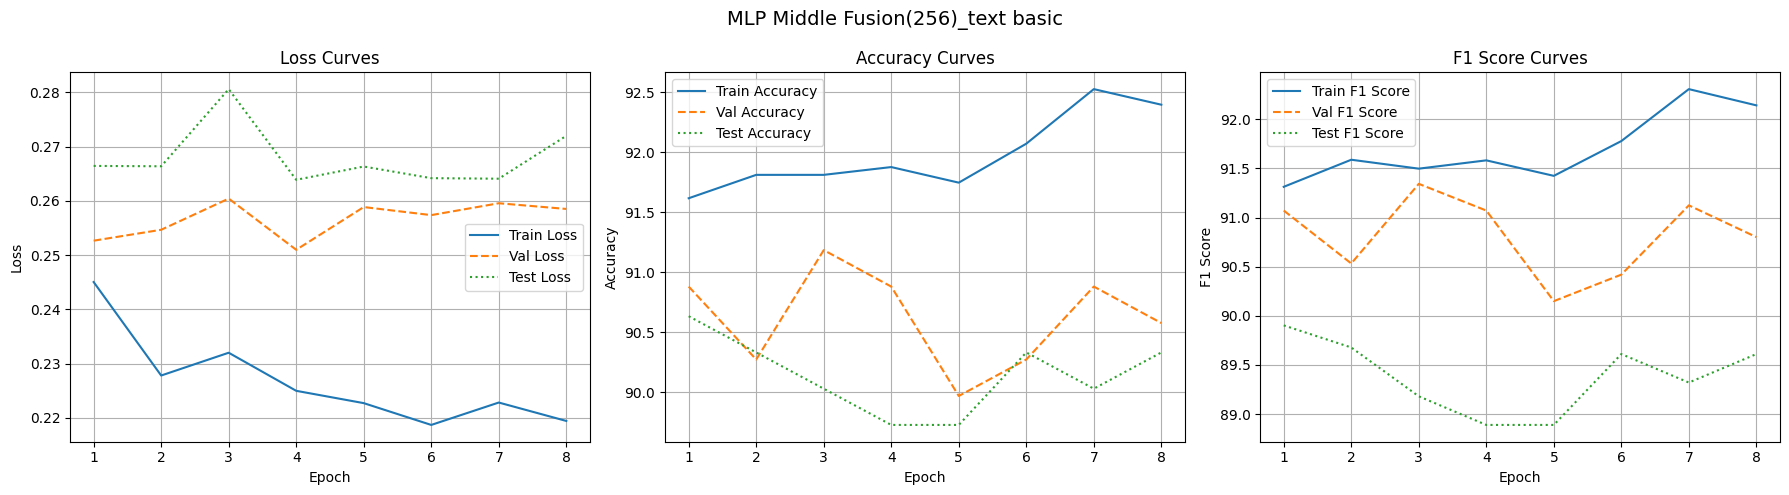

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ============
# x축 epoch 설정
# ============
epochs_range = range(1, len(history["train_loss"]) + 1)

# ============
# 0~1 값을 0~ 100 퍼센트로 변환
# ============
def to_percentage(values):
    values = np.array(values)
    if values.max() <= 1.5:
        return values * 100
    return values

train_acc = to_percentage(history["train_acc"])
val_acc = to_percentage(history["val_acc"])
test_acc = to_percentage(history["test_acc"])

train_f1 = to_percentage(history["train_f1"])
val_f1 = to_percentage(history["val_f1"])
test_f1 = to_percentage(history["test_f1"])

plt.figure(figsize=(18, 5))
plt.suptitle("MLP Middle Fusion(256)_text basic", fontsize=14)


# ============
# Loss 그래프 그리기
# ============

plt.subplot(1, 3, 1)

plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], linestyle="--", label="Val Loss")
plt.plot(epochs_range, history["test_loss"], linestyle=":", label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)


# ============
# Accuracy 그래프 그리기
# ============
plt.subplot(1, 3, 2)

plt.plot(epochs_range, train_acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, linestyle="--", label="Val Accuracy")
plt.plot(epochs_range, test_acc, linestyle=":", label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)

# ============
# F1 Score 그래프 그리기
# ============

plt.subplot(1, 3, 3)

plt.plot(epochs_range, train_f1, label="Train F1 Score")
plt.plot(epochs_range, val_f1, linestyle="--", label="Val F1 Score")
plt.plot(epochs_range, test_f1, linestyle=":", label="Test F1 Score")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score Curves")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

In [16]:
# ============================================================
# Modality Ablation Study
# Text / Audio / Video / Fusion 조합 비교
# ============================================================

feature_sets = {
    "Text only": X_text,
    "Audio only": X_audio,
    "Video only": X_video,
    "Text + Audio": torch.cat([X_text, X_audio], dim=1),
    "Text + Video": torch.cat([X_text, X_video], dim=1),
    "Audio + Video": torch.cat([X_audio, X_video], dim=1),
    "Text + Audio + Video": torch.cat([X_text, X_audio, X_video], dim=1)
}

results = []

for model_name, fused in feature_sets.items():
    print("\n==============================")
    print(f"Training: {model_name}")
    print("==============================")

    input_dim = fused.shape[1]

    # 기존과 같은 split 사용
    X_train = fused[train_idx]
    y_train = y[train_idx]

    X_val = fused[val_idx]
    y_val = y[val_idx]

    X_test = fused[test_idx]
    y_test = y[test_idx]

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=32,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=32,
        shuffle=False
    )

    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=32,
        shuffle=False
    )

    # 기존 MLP 구조 그대로 사용
    mlp = nn.Sequential(
        nn.Linear(input_dim, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 2)
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)

    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(20):
        mlp.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = mlp(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(mlp, val_loader)

        print(
            f"Epoch [{epoch+1}/20] "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = mlp.state_dict()

    # best validation 모델로 test 평가
    mlp.load_state_dict(best_model_state)

    test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(mlp, test_loader)

    results.append({
        "Model": model_name,
        "Input Dim": input_dim,
        "Test Loss": test_loss,
        "Test Acc": test_acc,
        "Test Precision": test_prec,
        "Test Recall": test_rec,
        "Test F1": test_f1
    })

# 결과표 확인
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test F1", ascending=False)

results_df



Training: Text only
Epoch [1/20] Val Loss: 0.2654, Val Acc: 0.9088, Val F1: 0.9102
Epoch [2/20] Val Loss: 0.2557, Val Acc: 0.9027, Val F1: 0.9059
Epoch [3/20] Val Loss: 0.2558, Val Acc: 0.9027, Val F1: 0.9059
Epoch [4/20] Val Loss: 0.2556, Val Acc: 0.9027, Val F1: 0.9059
Epoch [5/20] Val Loss: 0.2667, Val Acc: 0.9058, Val F1: 0.9086
Epoch [6/20] Val Loss: 0.2558, Val Acc: 0.9088, Val F1: 0.9112
Epoch [7/20] Val Loss: 0.2622, Val Acc: 0.9027, Val F1: 0.9059
Epoch [8/20] Val Loss: 0.2588, Val Acc: 0.9058, Val F1: 0.9086
Epoch [9/20] Val Loss: 0.2549, Val Acc: 0.9058, Val F1: 0.9086
Epoch [10/20] Val Loss: 0.2566, Val Acc: 0.9058, Val F1: 0.9086
Epoch [11/20] Val Loss: 0.2568, Val Acc: 0.9088, Val F1: 0.9112
Epoch [12/20] Val Loss: 0.2564, Val Acc: 0.9027, Val F1: 0.9059
Epoch [13/20] Val Loss: 0.2593, Val Acc: 0.9058, Val F1: 0.9086
Epoch [14/20] Val Loss: 0.2575, Val Acc: 0.8997, Val F1: 0.9032
Epoch [15/20] Val Loss: 0.2570, Val Acc: 0.9027, Val F1: 0.9059
Epoch [16/20] Val Loss: 0.25

c:\Users\User\AppData\Local\anaconda3\envs\main\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\anaconda3\envs\main\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch [2/20] Val Loss: 0.6969, Val Acc: 0.5198, Val F1: 0.6681
Epoch [3/20] Val Loss: 0.6974, Val Acc: 0.4833, Val F1: 0.0000
Epoch [4/20] Val Loss: 0.6981, Val Acc: 0.4833, Val F1: 0.0000


c:\Users\User\AppData\Local\anaconda3\envs\main\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch [5/20] Val Loss: 0.6983, Val Acc: 0.5319, Val F1: 0.6652
Epoch [6/20] Val Loss: 0.6981, Val Acc: 0.5198, Val F1: 0.6695
Epoch [7/20] Val Loss: 0.6973, Val Acc: 0.4863, Val F1: 0.0343


c:\Users\User\AppData\Local\anaconda3\envs\main\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch [8/20] Val Loss: 0.6973, Val Acc: 0.4833, Val F1: 0.0000
Epoch [9/20] Val Loss: 0.6966, Val Acc: 0.4924, Val F1: 0.1070
Epoch [10/20] Val Loss: 0.6977, Val Acc: 0.5137, Val F1: 0.6567
Epoch [11/20] Val Loss: 0.6971, Val Acc: 0.4863, Val F1: 0.3045
Epoch [12/20] Val Loss: 0.7011, Val Acc: 0.5137, Val F1: 0.6761
Epoch [13/20] Val Loss: 0.6984, Val Acc: 0.4833, Val F1: 0.0556
Epoch [14/20] Val Loss: 0.6969, Val Acc: 0.4924, Val F1: 0.0565
Epoch [15/20] Val Loss: 0.6949, Val Acc: 0.5380, Val F1: 0.6833
Epoch [16/20] Val Loss: 0.6976, Val Acc: 0.5137, Val F1: 0.6708
Epoch [17/20] Val Loss: 0.7006, Val Acc: 0.4863, Val F1: 0.0117
Epoch [18/20] Val Loss: 0.6988, Val Acc: 0.5167, Val F1: 0.6775
Epoch [19/20] Val Loss: 0.6978, Val Acc: 0.5198, Val F1: 0.6695
Epoch [20/20] Val Loss: 0.6965, Val Acc: 0.5289, Val F1: 0.3231

Training: Text + Audio
Epoch [1/20] Val Loss: 0.2498, Val Acc: 0.9149, Val F1: 0.9167
Epoch [2/20] Val Loss: 0.2532, Val Acc: 0.9058, Val F1: 0.9086
Epoch [3/20] Val Los

,Model,Input Dim,Test Loss,Test Acc,Test Precision,Test Recall,Test F1
3,Text + Audio,512,0.261684,0.906344,0.908497,0.891026,0.899676
6,Text + Audio + Video,768,0.264527,0.903323,0.902597,0.891026,0.896774
0,Text only,256,0.286710,0.897281,0.906667,0.871795,0.888889
4,Text + Video,512,0.282230,0.897281,0.906667,0.871795,0.888889
1,Audio only,256,0.547539,0.722054,0.707792,0.698718,0.703226
5,Audio + Video,512,0.538029,0.706949,0.695364,0.673077,0.684039
2,Video only,256,0.682540,0.561934,0.582090,0.250000,0.349776


1. Test Confusion Matrix 시각화

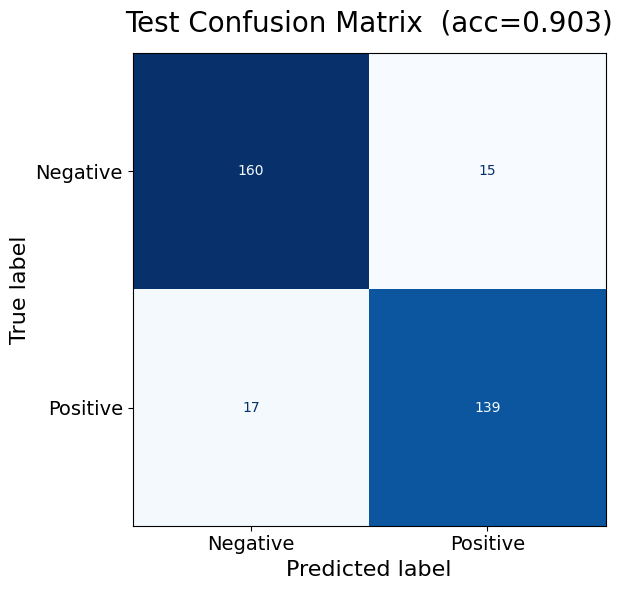

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# =========================
# Test 예측값 수집
# =========================
mlp.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = mlp(X_batch)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# =========================
# Confusion Matrix 계산
# =========================
cm = confusion_matrix(all_labels, all_preds)
test_acc = accuracy_score(all_labels, all_preds)

# =========================
# Confusion Matrix 시각화
# =========================
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title(f"Test Confusion Matrix  (acc={test_acc:.3f})", fontsize=20, pad=15)
ax.set_xlabel("Predicted label", fontsize=16)
ax.set_ylabel("True label", fontsize=16)

ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()
plt.show()

2. Ablation Study 그래프

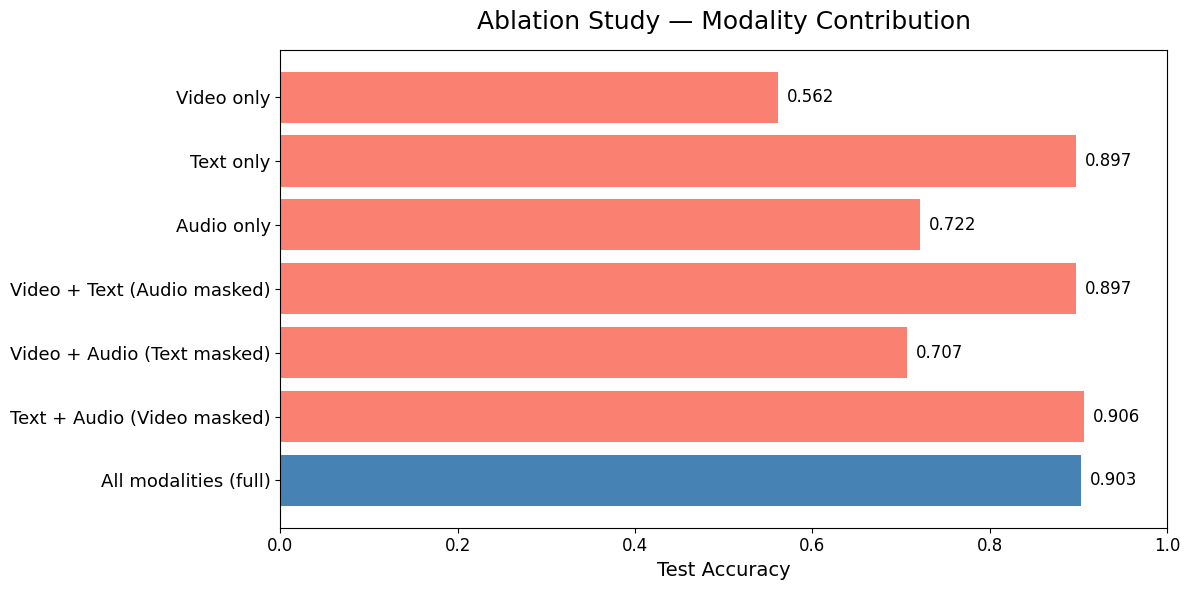

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# results_df 기준 Ablation 결과 정리
# =========================
ablation_df = results_df.copy()

# 기존 이름을 사진 스타일 이름으로 변경
name_map = {
    "Video only": "Video only",
    "Text only": "Text only",
    "Audio only": "Audio only",
    "Text + Video": "Video + Text (Audio masked)",
    "Audio + Video": "Video + Audio (Text masked)",
    "Text + Audio": "Text + Audio (Video masked)",
    "Text + Audio + Video": "All modalities (full)"
}

ablation_df["Plot Name"] = ablation_df["Model"].map(name_map)

# 사진과 같은 순서로 정렬
plot_order = [
    "Video only",
    "Text only",
    "Audio only",
    "Video + Text (Audio masked)",
    "Video + Audio (Text masked)",
    "Text + Audio (Video masked)",
    "All modalities (full)"
]

ablation_df["Plot Name"] = pd.Categorical(
    ablation_df["Plot Name"],
    categories=plot_order,
    ordered=True
)

ablation_df = ablation_df.sort_values("Plot Name")

labels = ablation_df["Plot Name"].tolist()
values = ablation_df["Test Acc"].tolist()

# All modalities만 파란색, 나머지는 살몬색
colors = [
    "steelblue" if label == "All modalities (full)" else "salmon"
    for label in labels
]

# =========================
# Ablation Study 시각화
# =========================
plt.figure(figsize=(12, 6))

bars = plt.barh(labels, values, color=colors)

plt.title("Ablation Study — Modality Contribution", fontsize=18, pad=15)
plt.xlabel("Test Accuracy", fontsize=14)
plt.xlim(0, 1.0)

plt.xticks(fontsize=12)
plt.yticks(fontsize=13)

# 막대 오른쪽에 수치 표시
for bar, value in zip(bars, values):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=12
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

3. Loss, Accuracy, F1 Learning Curves

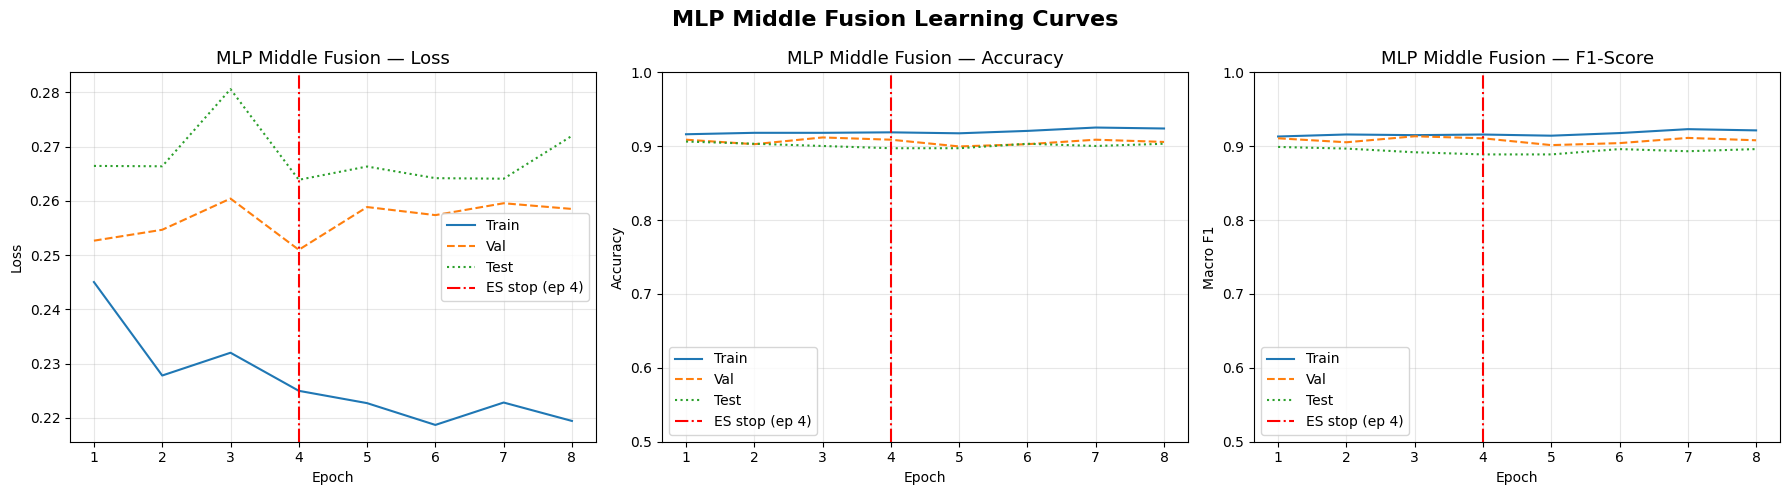

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Epoch 설정
# =========================
epochs_range = range(1, len(history["train_loss"]) + 1)

# Early Stopping 표시 위치
# best_epoch이 있으면 best_epoch+1 사용, 없으면 마지막 epoch 사용
try:
    es_epoch = best_epoch + 1
except:
    es_epoch = len(history["train_loss"])

# =========================
# Learning Curves 시각화
# =========================
plt.figure(figsize=(18, 5))
plt.suptitle("MLP Middle Fusion Learning Curves", fontsize=16, fontweight="bold")

# =========================
# 1. Loss Curve
# =========================
plt.subplot(1, 3, 1)

plt.plot(epochs_range, history["train_loss"], label="Train")
plt.plot(epochs_range, history["val_loss"], linestyle="--", label="Val")
plt.plot(epochs_range, history["test_loss"], linestyle=":", label="Test")

plt.axvline(
    x=es_epoch,
    color="red",
    linestyle="-.",
    label=f"ES stop (ep {es_epoch})"
)

plt.title("MLP Middle Fusion — Loss", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

# =========================
# 2. Accuracy Curve
# =========================
plt.subplot(1, 3, 2)

plt.plot(epochs_range, history["train_acc"], label="Train")
plt.plot(epochs_range, history["val_acc"], linestyle="--", label="Val")
plt.plot(epochs_range, history["test_acc"], linestyle=":", label="Test")

plt.axvline(
    x=es_epoch,
    color="red",
    linestyle="-.",
    label=f"ES stop (ep {es_epoch})"
)

plt.title("MLP Middle Fusion — Accuracy", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()

# =========================
# 3. F1 Score Curve
# =========================
plt.subplot(1, 3, 3)

plt.plot(epochs_range, history["train_f1"], label="Train")
plt.plot(epochs_range, history["val_f1"], linestyle="--", label="Val")
plt.plot(epochs_range, history["test_f1"], linestyle=":", label="Test")

plt.axvline(
    x=es_epoch,
    color="red",
    linestyle="-.",
    label=f"ES stop (ep {es_epoch})"
)

plt.title("MLP Middle Fusion — F1-Score", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.ylim(0.5, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()